# Exploratory Data Analysis

Before building anything, understand the data. This notebook walks through the structure, statistics, and key patterns in the dataset. Run every cell and read the outputs carefully — your state space and reward function decisions should be informed by what you find here.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import load_prices, build_features

INTERVAL = '1h'   # change to '30m' or '15m' if you downloaded those
data = load_prices(INTERVAL)

ASSETS = ['asset_0', 'asset_1', 'asset_2']
COLORS = ['#2196F3', '#FF9800', '#4CAF50']

print(f'Shape  : {data.shape}')
print(f'From   : {data.index[0]}')
print(f'To     : {data.index[-1]}')
print(f'Columns: {list(data.columns)}')

Shape  : (70005, 16)
From   : 2018-01-01 00:59:59.999000
To     : 2025-12-31 00:59:59.999000
Columns: ['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 'cash']


In [ ]:
'asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 
'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 
'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 
'cash'

In [5]:
data

,asset_0_close,asset_0_high,asset_0_low,asset_0_volume,asset_0_taker_buy_ratio,asset_1_close,asset_1_high,asset_1_low,asset_1_volume,asset_1_taker_buy_ratio,asset_2_close,asset_2_high,asset_2_low,asset_2_volume,asset_2_taker_buy_ratio,cash
2018-01-01 00:59:59.999,55.970769,56.501538,55.386923,2105.90100,0.605552,2.785300,2.849267,2.748667,49487.140,0.326208,71.205316,72.187632,70.526368,443.356199,0.515436,1.0
2018-01-01 01:59:59.999,55.228462,56.307692,55.138462,2305.97086,0.448980,2.739967,2.799900,2.710167,24992.630,0.412091,69.489789,71.557316,69.238842,383.697006,0.471310,1.0
2018-01-01 02:59:59.999,55.696154,55.826923,55.199231,2166.45725,0.544589,2.741167,2.782933,2.734000,28933.000,0.287814,70.158842,70.623316,69.473684,429.064572,0.448040,1.0
2018-01-01 03:59:59.999,56.500000,56.768462,55.592308,2160.90450,0.507025,2.780033,2.810867,2.742733,32931.170,0.573935,70.579105,71.638263,69.947368,420.087030,0.328309,1.0
2018-01-01 04:59:59.999,57.293846,57.306154,56.154615,2335.33705,0.562245,2.833333,2.833333,2.780333,14602.550,0.626524,71.584263,71.701526,70.116579,340.807329,0.507494,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 20:59:59.999,227.603077,228.760769,227.422308,6004.61810,0.428787,286.233333,286.763333,286.166667,1951.285,0.400958,462.879737,464.348158,462.560316,439.950210,0.557202,1.0
2025-12-30 21:59:59.999,228.356154,228.418462,227.252308,5039.14100,0.613814,287.076667,287.080000,286.110000,1851.502,0.547264,464.669842,464.895421,462.585000,253.184320,0.655206,1.0
2025-12-30 22:59:59.999,228.426154,228.623846,228.119231,6111.92850,0.433188,287.196667,287.603333,286.870000,1431.850,0.512653,465.422053,465.631579,464.669895,280.865970,0.449011,1.0
2025-12-30 23:59:59.999,228.745385,228.920000,228.276154,5294.94260,0.589171,287.216667,287.686667,287.033333,2100.957,0.492628,465.713105,466.177105,465.112263,270.666520,0.623981,1.0


In [6]:
data.columns

Index(['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume',
       'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high',
       'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio',
       'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume',
       'asset_2_taker_buy_ratio', 'cash'],
      dtype='str')

## 1. Price History

Prices are normalized to 100 at the start so all three assets are on the same scale.

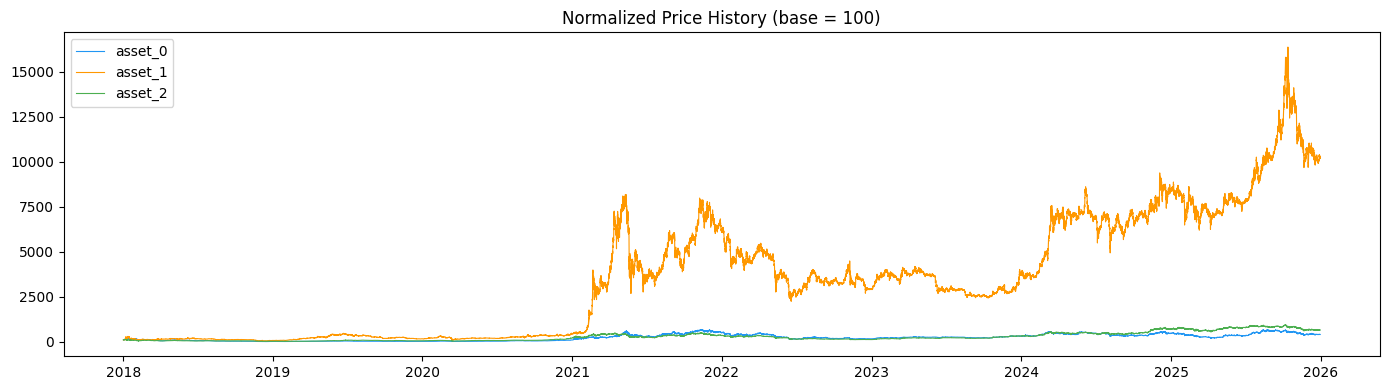


Total return over full period:
  asset_0: 308%
  asset_1: 10185%
  asset_2: 552%


In [4]:
closes = data[[f'{a}_close' for a in ASSETS]].rename(columns={f'{a}_close': a for a in ASSETS})
normalized = closes / closes.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 4))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(normalized.index, normalized[asset], label=asset, color=color, linewidth=0.8)
ax.set_title('Normalized Price History (base = 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('\nTotal return over full period:')
for asset in ASSETS:
    ret = (closes[asset].iloc[-1] / closes[asset].iloc[0] - 1) * 100
    print(f'  {asset}: {ret:.0f}%')

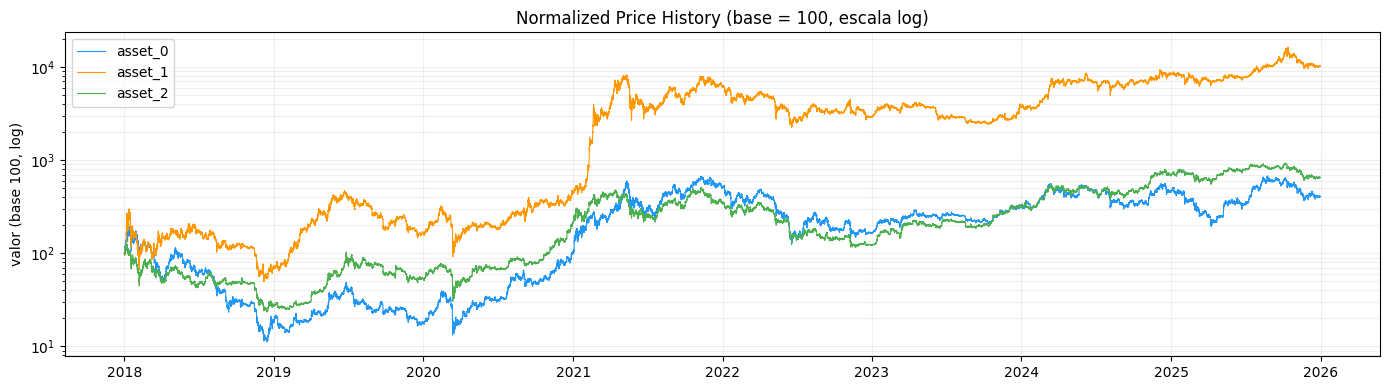

In [13]:
closes = data[[f'{a}_close' for a in ASSETS]].rename(columns={f'{a}_close': a for a in ASSETS})
normalized = closes / closes.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 4))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(normalized.index, normalized[asset], label=asset, color=color, linewidth=0.8)
ax.set_yscale('log')                       # <-- escala logarítmica
ax.set_title('Normalized Price History (base = 100, escala log)')
ax.set_ylabel('valor (base 100, log)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Return Distributions

Log-returns are what your agent ultimately works with. Notice the fat tails — large moves happen much more often than a normal distribution would predict.

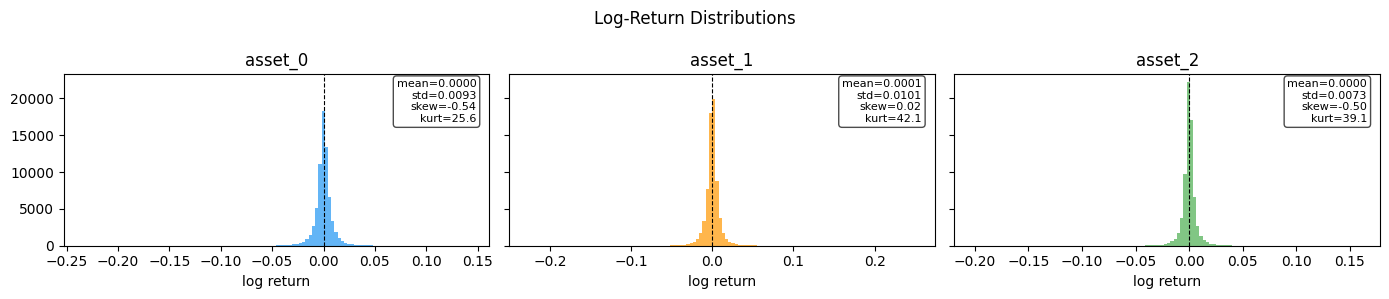

In [7]:
log_rets = np.log(closes / closes.shift(1)).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, asset, color in zip(axes, ASSETS, COLORS):
    r = log_rets[asset]
    ax.hist(r, bins=120, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(asset)
    ax.set_xlabel('log return')
    stats = f"mean={r.mean():.4f}\nstd={r.std():.4f}\nskew={r.skew():.2f}\nkurt={r.kurtosis():.1f}"
    ax.text(0.97, 0.97, stats, transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.suptitle('Log-Return Distributions')
plt.tight_layout()
plt.show()

## 3. Rolling Volatility

Volatility is not constant — it clusters. Calm periods and turbulent periods alternate. This is a key challenge for your agent: what works in a low-volatility regime may fail in a high-volatility one.

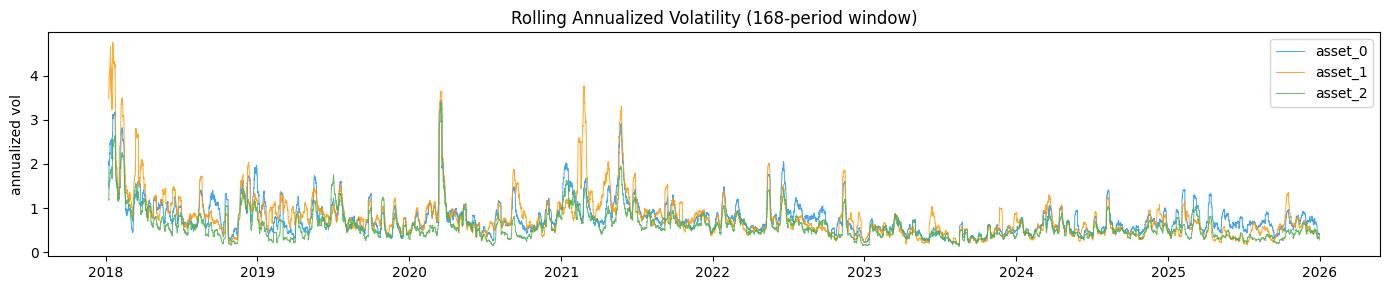

In [8]:
window = 24 * 7  # one week of hourly candles
vol = log_rets.rolling(window).std() * np.sqrt(24 * 365)  # annualized

fig, ax = plt.subplots(figsize=(14, 3))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(vol.index, vol[asset], label=asset, color=color, linewidth=0.7, alpha=0.85)
ax.set_title(f'Rolling Annualized Volatility ({window}-period window)')
ax.set_ylabel('annualized vol')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [14]:
vol

,asset_0,asset_1,asset_2
2018-01-01 01:59:59.999,NaN,NaN,NaN
2018-01-01 02:59:59.999,NaN,NaN,NaN
2018-01-01 03:59:59.999,NaN,NaN,NaN
2018-01-01 04:59:59.999,NaN,NaN,NaN
2018-01-01 05:59:59.999,NaN,NaN,NaN
...,...,...,...
2025-12-30 20:59:59.999,0.378859,0.273942,0.319560
2025-12-30 21:59:59.999,0.379434,0.274384,0.320754
2025-12-30 22:59:59.999,0.378067,0.273843,0.319804
2025-12-30 23:59:59.999,0.378097,0.273691,0.319759


## 4. Correlation Between Assets

How correlated are the assets? High correlation means diversification offers less benefit. It also affects how your agent should think about portfolio construction.

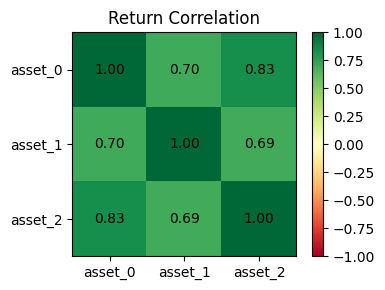

In [9]:
corr = log_rets.corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(len(ASSETS))); ax.set_xticklabels(ASSETS)
ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(ASSETS)
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Return Correlation')
plt.tight_layout()
plt.show()

## 5. Volume and Taker Buy Ratio

Volume spikes often precede or coincide with large price moves. The taker buy ratio (fraction of volume initiated by buyers) is a microstructure signal of short-term directional pressure.

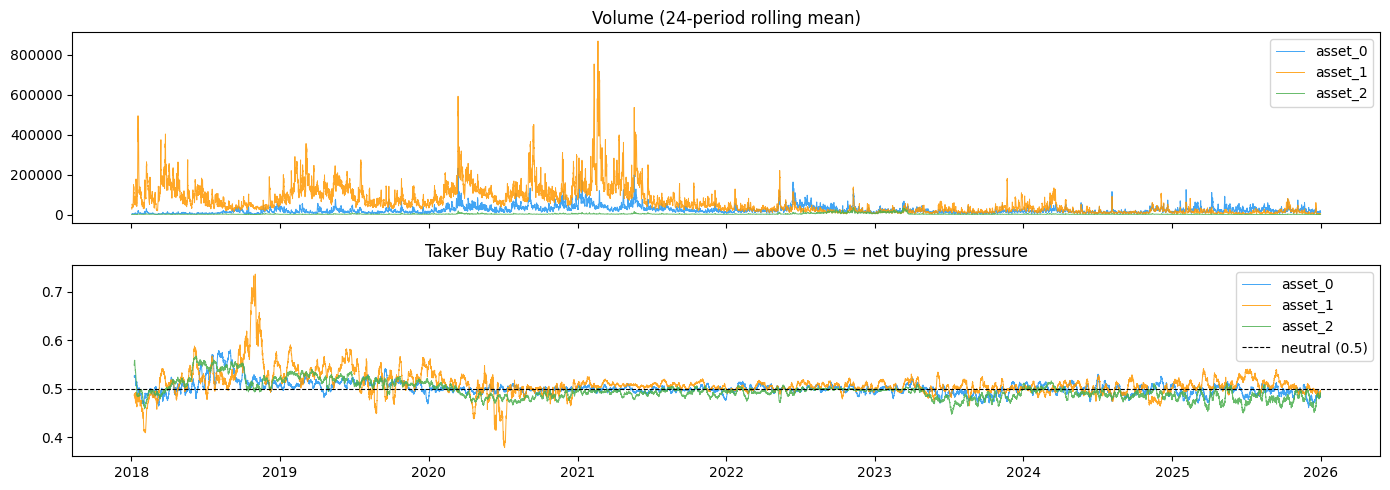

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# Volume (rolling mean to smooth)
for asset, color in zip(ASSETS, COLORS):
    vol_series = data[f'{asset}_volume'].rolling(24).mean()
    axes[0].plot(vol_series.index, vol_series, label=asset, color=color, linewidth=0.7, alpha=0.85)
axes[0].set_title('Volume (24-period rolling mean)')
axes[0].legend()

# Taker buy ratio
for asset, color in zip(ASSETS, COLORS):
    tbr = data[f'{asset}_taker_buy_ratio'].rolling(24 * 7).mean()
    axes[1].plot(tbr.index, tbr, label=asset, color=color, linewidth=0.7, alpha=0.85)
axes[1].axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='neutral (0.5)')
axes[1].set_title('Taker Buy Ratio (7-day rolling mean) — above 0.5 = net buying pressure')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 6. Drawdown Profile

What does the worst-case look like for each asset? This should calibrate your expectations for how bad things can get, and inform your reward function design.

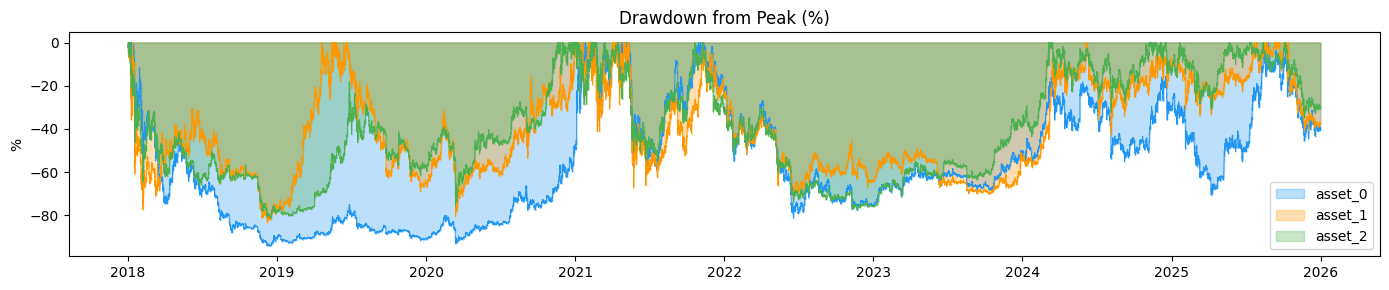

Max drawdown:
  asset_0: -94.3%
  asset_1: -83.4%
  asset_2: -81.4%


In [11]:
fig, ax = plt.subplots(figsize=(14, 3))
for asset, color in zip(ASSETS, COLORS):
    price = closes[asset]
    peak = price.cummax()
    dd = (price - peak) / peak * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color=color, label=asset)
    ax.plot(dd.index, dd, color=color, linewidth=0.6)
ax.set_title('Drawdown from Peak (%)')
ax.set_ylabel('%')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('Max drawdown:')
for asset in ASSETS:
    price = closes[asset]
    peak = price.cummax()
    print(f'  {asset}: {((price - peak) / peak).min() * 100:.1f}%')

## 7. Pre-computed Features

A preview of what `build_features()` produces — these are available for your observation space out of the box.

In [12]:
features, _ = build_features(data, fit=True)
print(f'Feature matrix shape: {features.shape}')
print(f'\nFeatures available:')
for col in features.columns:
    print(f'  {col}')
print(f'\nSample (last 3 rows):')
features.tail(3).round(3)

Feature matrix shape: (69984, 18)

Features available:
  asset_0_log_ret
  asset_0_vol_21
  asset_0_mom_20
  asset_0_atr_14
  asset_0_vol_ratio
  asset_0_tbr
  asset_1_log_ret
  asset_1_vol_21
  asset_1_mom_20
  asset_1_atr_14
  asset_1_vol_ratio
  asset_1_tbr
  asset_2_log_ret
  asset_2_vol_21
  asset_2_mom_20
  asset_2_atr_14
  asset_2_vol_ratio
  asset_2_tbr

Sample (last 3 rows):


,asset_0_log_ret,asset_0_vol_21,asset_0_mom_20,asset_0_atr_14,asset_0_vol_ratio,asset_0_tbr,asset_1_log_ret,asset_1_vol_21,asset_1_mom_20,asset_1_atr_14,asset_1_vol_ratio,asset_1_tbr,asset_2_log_ret,asset_2_vol_21,asset_2_mom_20,asset_2_atr_14,asset_2_vol_ratio,asset_2_tbr
2025-12-30 22:59:59.999,0.031,-0.828,0.335,-0.682,-0.749,-1.128,0.035,-0.853,0.285,-0.858,-0.829,0.037,0.218,-0.698,0.460,-0.575,-0.786,-0.809
2025-12-30 23:59:59.999,0.148,-0.845,0.171,-0.711,-0.833,1.480,0.000,-0.877,0.213,-0.865,-0.531,-0.187,0.082,-0.715,0.382,-0.599,-0.800,2.184
2025-12-31 00:59:59.999,-0.266,-0.921,0.158,-0.721,-0.887,0.726,-0.264,-0.873,0.156,-0.852,-0.473,-1.569,-0.360,-0.707,0.329,-0.601,-0.849,0.338


## Key Takeaways

Before moving to `agent.py`, make sure you can answer:

1. **Volatility is regime-dependent.** Your agent will train on some regimes and be evaluated on others. How should your state capture this?
2. **Assets are correlated but not identical.** Diversification has value, but not as much as with truly uncorrelated assets.
3. **Drawdowns are severe.** A naive hold strategy can lose 80%+. Your reward function needs to account for this.
4. **Volume and taker buy ratio carry information.** Whether to include them in your state is a design decision — justify it.
5. **The data is noisy.** Do not expect your agent to find a clean signal. Focus on robustness over peak performance.